In [ ]:
EXPERIMENTAL_ID="recommend_home_202511"
START_DATE="2025-11-21"

In [ ]:
from odps_client import get_odps_sql_result_as_df
from datetime import datetime, timedelta


In [ ]:
from sls_client import get_sls_data_by_query
from datetime import datetime, timedelta
import pandas as pd

# 设置pandas显示选项以展示更多内容
pd.set_option("display.max_rows", 100)  # 显示最多100行
pd.set_option("display.max_columns", None)  # 显示所有列
pd.set_option("display.width", 1000)  # 设置显示宽度
pd.set_option("display.max_colwidth", 100)  # 设置列最大宽度

import sqlite3


def get_user_variant_of_date_from_sls(
    day: datetime, check_if_local_exist: bool = True
) -> pd.DataFrame:
    """
    从SLS(Simple Log Service)获取指定日期的用户变体数据。

    Args:
        day (datetime): 要获取数据的日期。
        check_if_local_exist (bool): 是否检查本地数据库中是否已存在数据，默认为True。

    Returns:
        pd.DataFrame: 包含用户变体数据的DataFrame。
    """
    # 构建数据库文件名和表名
    db_file_name = f"./data/recommend_ab_user_variant.db"
    table_name = f"recommend_ab_user_variant_{day.strftime('%Y%m%d')}"
    # 连接到SQLite数据库
    conn = sqlite3.connect(db_file_name)

    # 如果设置为检查本地数据
    if check_if_local_exist:
        try:
            # 尝试从数据库中读取数据
            query = f"SELECT * FROM {table_name}"
            df = pd.read_sql_query(query, conn)
            # 关闭数据库连接
            conn.close()
            # 返回读取的数据
            return df
        except pd.io.sql.DatabaseError:
            # 如果表不存在，则忽略错误
            pass

    # 构建SLS查询语句
    query = f"""
type:a and ap:/recommend/ and pageName:/home and not ap:/recommend/tab
| SELECT 
    regexp_replace(ap, '\d+','{{digit}}') as api,
    pageName as page_name,
    regexp_extract(experiment_item, '"experimentId":"([^"]+)"', 1) as experiment_id,
    type,
    uid,
    date_format(__time__, '%Y%m%d') as ds,
    count(1) as search_times,
    array_join(array_sort(array_agg(distinct regexp_extract(experiment_item, '"variantId":"([^"]+)"', 1))),',') as variant_list
FROM log, 
UNNEST(regexp_extract_all(json_extract_scalar(ai, '$.qh.xm-ab-exp'), '\{{[^}}]+\}}')) as t(experiment_item)
WHERE experiment_item LIKE '%"experimentId":"{EXPERIMENTAL_ID}"%'
GROUP BY 1,2,3,4,5,6
LIMIT 1000000
"""
    # 设置查询的起始时间和结束时间
    print(query)
    from_time = day.replace(hour=0, minute=0, second=0, microsecond=0)
    to_time = day.replace(hour=23, minute=59, second=59, microsecond=999999)
    # 从SLS获取数据
    _df = get_sls_data_by_query(
        query=query,
        project="xianmu-front-end-log",  # 指定SLS项目
        logstore="xm-mall",  # 指定SLS日志库
        from_time=from_time,  # 指定查询起始时间
        to_time=to_time,  # 指定查询结束时间
    )

    # 将search_times列中的缺失值填充为1，并转换为整数类型
    _df["search_times"] = _df["search_times"].fillna(1).astype(int)
    # 将variant_list列中的缺失值填充为"none"
    _df["variant_list"] = _df["variant_list"].fillna("none")

    # 如果DataFrame不为空
    if not _df.empty:
        # 删除不需要的列
        _df.drop(columns=["__source__", "__time__"], inplace=True)
        # 将数据写入SQLite数据库，如果表已存在则替换
        _df.to_sql(table_name, conn, if_exists="replace", index=False)
    # 关闭数据库连接
    conn.close()
    # 返回数据
    return _df


# 创建一个空的DataFrame来存储所有日期的用户变体数据
all_user_variant_df = pd.DataFrame()
# 设置起始日期和结束日期
start_date = datetime.strptime(START_DATE, "%Y-%m-%d")
end_date = datetime.now()
# 从起始日期开始循环，直到结束日期
current_date = start_date
while current_date <= end_date:
    # 检查是否是今天
    is_today = current_date.strftime("%Y%m%d") == end_date.strftime("%Y%m%d")
    # 如果是今天,则跳过，因为今天的数据可能不完整
    if is_today:
        print(f"今天的数据还未完整，跳过:{current_date}")
        break
    # 获取当前日期的用户变体数据
    df = get_user_variant_of_date_from_sls(current_date, check_if_local_exist=True)
    # 将当前日期的数据添加到总的DataFrame中
    all_user_variant_df = pd.concat([all_user_variant_df, df], ignore_index=True)
    # 日期增加一天
    current_date += timedelta(days=1)

# 显示前10行数据
all_user_variant_df.head(10)

In [ ]:
import pandasql
stats=pandasql.sqldf("""select ds,variant_list,count(distinct uid) unique_user 
                     from all_user_variant_df group by ds,variant_list order by ds desc,variant_list""")

display(stats)

In [ ]:
# idx:4,name:徐州奶油草莓 净重3-3.2斤/一级/单果10g+/板装,pid:goods,sku:5442468008,salePrice:69.5,pdid:702,stock:10000,ext:cross;idx:5,name:徐州奶油草莓 280G*1盒/一级/4*6/ ,pid:goods,sku:5442468073,salePrice:16.5,pdid:702,stock:10000,ext:cross;idx:6,name:徐州奶油草莓 净重2.8-3斤/一级/单果10g+/ 10盒,pid:goods,sku:5442468518,salePrice:74.5,pdid:702,stock:10000,ext:cross

view_query = """
type:cl or type:view | select ds,
    pageName as "页面名称",uid,
    count(case when type='view' and position_id='goods' then 1 end) as "SKU曝光次数",
    count(distinct case when type='view' and position_id='goods' then sku_viewd_or_clicked end) as "被查看SKU数",
    count(distinct case when type='cl' and position_id in ('goods','唤起购买') then sku_viewd_or_clicked end) as "被点击SKU数",
    count(case when type='cl' and position_id in ('goods','唤起购买') then 1 end) as "SKU点击次数",
    round(1.00*count(case when type='cl' and position_id in ('goods','唤起购买') then 1 end)/ count(case when type='view' and position_id='goods' then 1 end),4) as "SKU点击率",
    count(case when type='cl' and position_id in ('goods','唤起购买') and idx <= 3 then 1 end) as "前4位SKU点击次数",
    round(1.00*count(case when type='cl' and position_id in ('goods','唤起购买') and idx <= 3 then 1 end)/count(case when type='cl' and position_id in ('goods','唤起购买') then 1 end),2) as "前4位SKU点击占比",
    count(case when type='cl' and position_id='唤起购买' then 1 end) as "唤起加购弹窗点击次数",
    count(case when type='cl' and position_id='加购弹窗' and position_name='加入购物车' then 1 end) as "加入购物车次数",
    count(case when type='cl' and position_id='加购弹窗' and position_name='立即购买' then 1 end) as "立即购买次数",
    round(avg(case when type='cl' then idx end),2) as "平均点击位置",
    max(case when type='cl' then idx end) as "最大点击位置",
    approx_percentile(case when type='cl' then idx end, 0.5) as "点击位置P50",
    approx_percentile(case when type='cl' then idx end, 0.75) as "点击位置P75",
    approx_percentile(case when type='cl' then idx end, 0.95) as "点击位置P95",
    approx_percentile(case when type='view' and position_id = 'goods' then idx end, 0.5) as "查看位置P50",
    approx_percentile(case when type='view' and position_id = 'goods' then idx end, 0.75) as "查看位置P75",
    approx_percentile(case when type='view' and position_id = 'goods' then idx end, 0.95) as "查看位置P95",
    count(0) as "总事件数" 
from (
    select pageName,
        type,
        case when COALESCE(regexp_extract(bid, 'pid:([^,]+)', 1),pid) in ('goods','唤起购买') and type='cl' 
            then COALESCE(regexp_extract(bid, 'pid:([^,]+)', 1),pid) 
            else COALESCE(regexp_extract(bid, 'name:([^,]+)', 1),name) 
        end as position_name,
        COALESCE(regexp_extract(bid, 'pid:([^,]+)', 1),pid) as position_id,
        uid,
        cast(COALESCE(regexp_extract(bid, 'idx:([0-9]+)', 1),idx) as bigint) as idx,
        COALESCE(regexp_extract(bid, 'sku:([0-9a-zA-Z]{1,20})', 1),sku) as sku_viewd_or_clicked,
        date_format(__time__,'%Y%m%d') ds
    from log 
    where pageName like '/home%'
        and COALESCE(regexp_extract(bid, 'sku:([0-9a-zA-Z]{1,20})', 1),sku) is not null 
    limit 100000000
)
group by 1,2,3
having length(uid)>0
order by 4 desc
"""


def get_user_sku_view_of_date_from_sls(
    day: datetime, check_if_local_exist: bool = True
) -> pd.DataFrame:
    db_file_name = f"./data/recommend_ab_user_sku_view.db"
    table_name = f"user_sku_view_{day.strftime('%Y%m%d')}"
    conn = sqlite3.connect(db_file_name)
    cursor = conn.cursor()

    if check_if_local_exist:
        try:
            query = f"SELECT * FROM {table_name}"
            df = pd.read_sql_query(query, conn)
            conn.close()
            return df
        except pd.io.sql.DatabaseError:
            pass

    from_time = day.replace(hour=0, minute=0, second=0, microsecond=0)
    to_time = day.replace(hour=23, minute=59, second=59, microsecond=999999)
    _df = get_sls_data_by_query(
        query=view_query,
        project="xianmu-front-end-log",
        logstore="xm-mall",
        from_time=from_time,
        to_time=to_time,
    )

    if not _df.empty:
        _df.drop(columns=["__source__", "__time__"], inplace=True)
        _df.to_sql(table_name, conn, if_exists="replace", index=False)
    conn.close()
    return _df


all_user_sku_view_df = pd.DataFrame()
current_date = start_date
while current_date <= end_date:
    is_today = current_date.strftime("%Y%m%d") == end_date.strftime("%Y%m%d")
    if is_today:
        print(f"今天的数据还未完整，跳过:{current_date}")
        break
    df = get_user_sku_view_of_date_from_sls(current_date, check_if_local_exist=True)
    all_user_sku_view_df = pd.concat([all_user_sku_view_df, df], ignore_index=True)
    current_date += timedelta(days=1)

In [ ]:
all_user_sku_view_df['前4位SKU点击占比']=all_user_sku_view_df['前4位SKU点击占比'].fillna(0.0).astype(float)
all_user_sku_view_df.head(20)

In [ ]:
all_user_sku_view_df.groupby("ds").size().reset_index(name="count").sort_values(
    "count", ascending=False
).head(10)

In [ ]:
user_click_with_variant_statistics_df = all_user_sku_view_df.merge(
    all_user_variant_df[["uid", "ds", "variant_list"]],
    on=["uid", "ds"],
    how="left",
)

user_click_with_variant_statistics_df.head(5)
user_click_with_variant_statistics_df['SKU点击次数'] = user_click_with_variant_statistics_df['SKU点击次数'].astype(int)

for variant_list, group_df in user_click_with_variant_statistics_df.groupby('variant_list'):
    print(variant_list)
    print(group_df['SKU点击次数'].describe().to_json(), group_df['SKU点击次数'].quantile([0.5, 0.75, 0.95, 0.99, 0.999]).to_json())

In [ ]:
print(user_click_with_variant_statistics_df.columns)
print(user_click_with_variant_statistics_df.head(5).to_json(force_ascii=False))

✓ 成功设置中文字体: PingFang SC


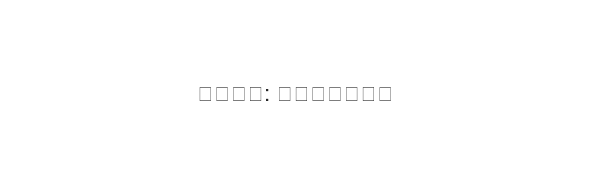

✓ 中文字体配置完成


In [11]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import platform

def setup_chinese_font():
    """
    设置matplotlib中文字体（macOS优化版）
    """
    system = platform.system()
    
    if system == 'Darwin':  # macOS
        # macOS常见中文字体列表（按优先级排序）
        mac_fonts = [
            'PingFang SC',      # 苹方-简（macOS默认中文字体）
            'Heiti SC',         # 黑体-简
            'STHeiti',          # 华文黑体
            'Arial Unicode MS', # Arial Unicode MS
            'Songti SC',        # 宋体-简
            'STSong',           # 华文宋体
        ]
        
        # 尝试设置字体
        for font in mac_fonts:
            try:
                plt.rcParams['font.sans-serif'] = [font] + plt.rcParams['font.sans-serif']
                print(f"✓ 成功设置中文字体: {font}")
                break
            except:
                continue
    
    elif system == 'Windows':
        plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
        print("✓ 成功设置中文字体: Windows")
    
    elif system == 'Linux':
        plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Droid Sans Fallback', 'DejaVu Sans']
        print("✓ 成功设置中文字体: Linux")
    
    # 解决负号显示问题
    plt.rcParams['axes.unicode_minus'] = False
    
    # 验证字体设置
    test_fig, test_ax = plt.subplots(figsize=(6, 2))
    test_ax.text(0.5, 0.5, '中文测试: 实验组对比分析', 
                 fontsize=16, ha='center', va='center')
    test_ax.set_xlim(0, 1)
    test_ax.set_ylim(0, 1)
    test_ax.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close()
    
    print("✓ 中文字体配置完成")

# 执行字体设置
setup_chinese_font()

✓ 字体已配置: PingFang SC
数据清理与预处理

原始数据总样本量: 17416
分组列缺失值数量: 6282

清理无效数据...

各列无效值统计:
  SKU点击率: 153 (1.4%)
  前4位SKU点击占比: 7141 (64.1%)
  平均点击位置: 7141 (64.1%)
  最大点击位置: 7141 (64.1%)
  点击位置P50: 7141 (64.1%)
  点击位置P75: 7141 (64.1%)
  点击位置P95: 7141 (64.1%)
  查看位置P50: 153 (1.4%)
  查看位置P75: 153 (1.4%)
  查看位置P95: 153 (1.4%)

清理后样本量: 11134

实验组: ['V1', 'V2', 'V3', 'V4']

各组样本量分布:
  V1: 2795 (25.1%)
  V2: 2808 (25.2%)
  V3: 2735 (24.6%)
  V4: 2796 (25.1%)


                    实验组对比完整分析报告

一、描述性统计分析

指标: SKU点击率
               样本量      均值  中位数     标准差  最小值  最大值     标准误  95%CI下限  95%CI上限
variant_list                                                               
V1            2763  0.0656  0.0  0.1718  0.0  2.0  0.0033   0.0592   0.0720
V2            2769  0.0595  0.0  0.1518  0.0  2.0  0.0029   0.0539   0.0652
V3            2695  0.0540  0.0  0.1604  0.0  4.0  0.0031   0.0479   0.0600
V4            2754  0.0665  0.0  0.1926  0.0  3.0  0.0037   0.0593   0.0737

指标: 被点击SKU数
               样本量      均值 

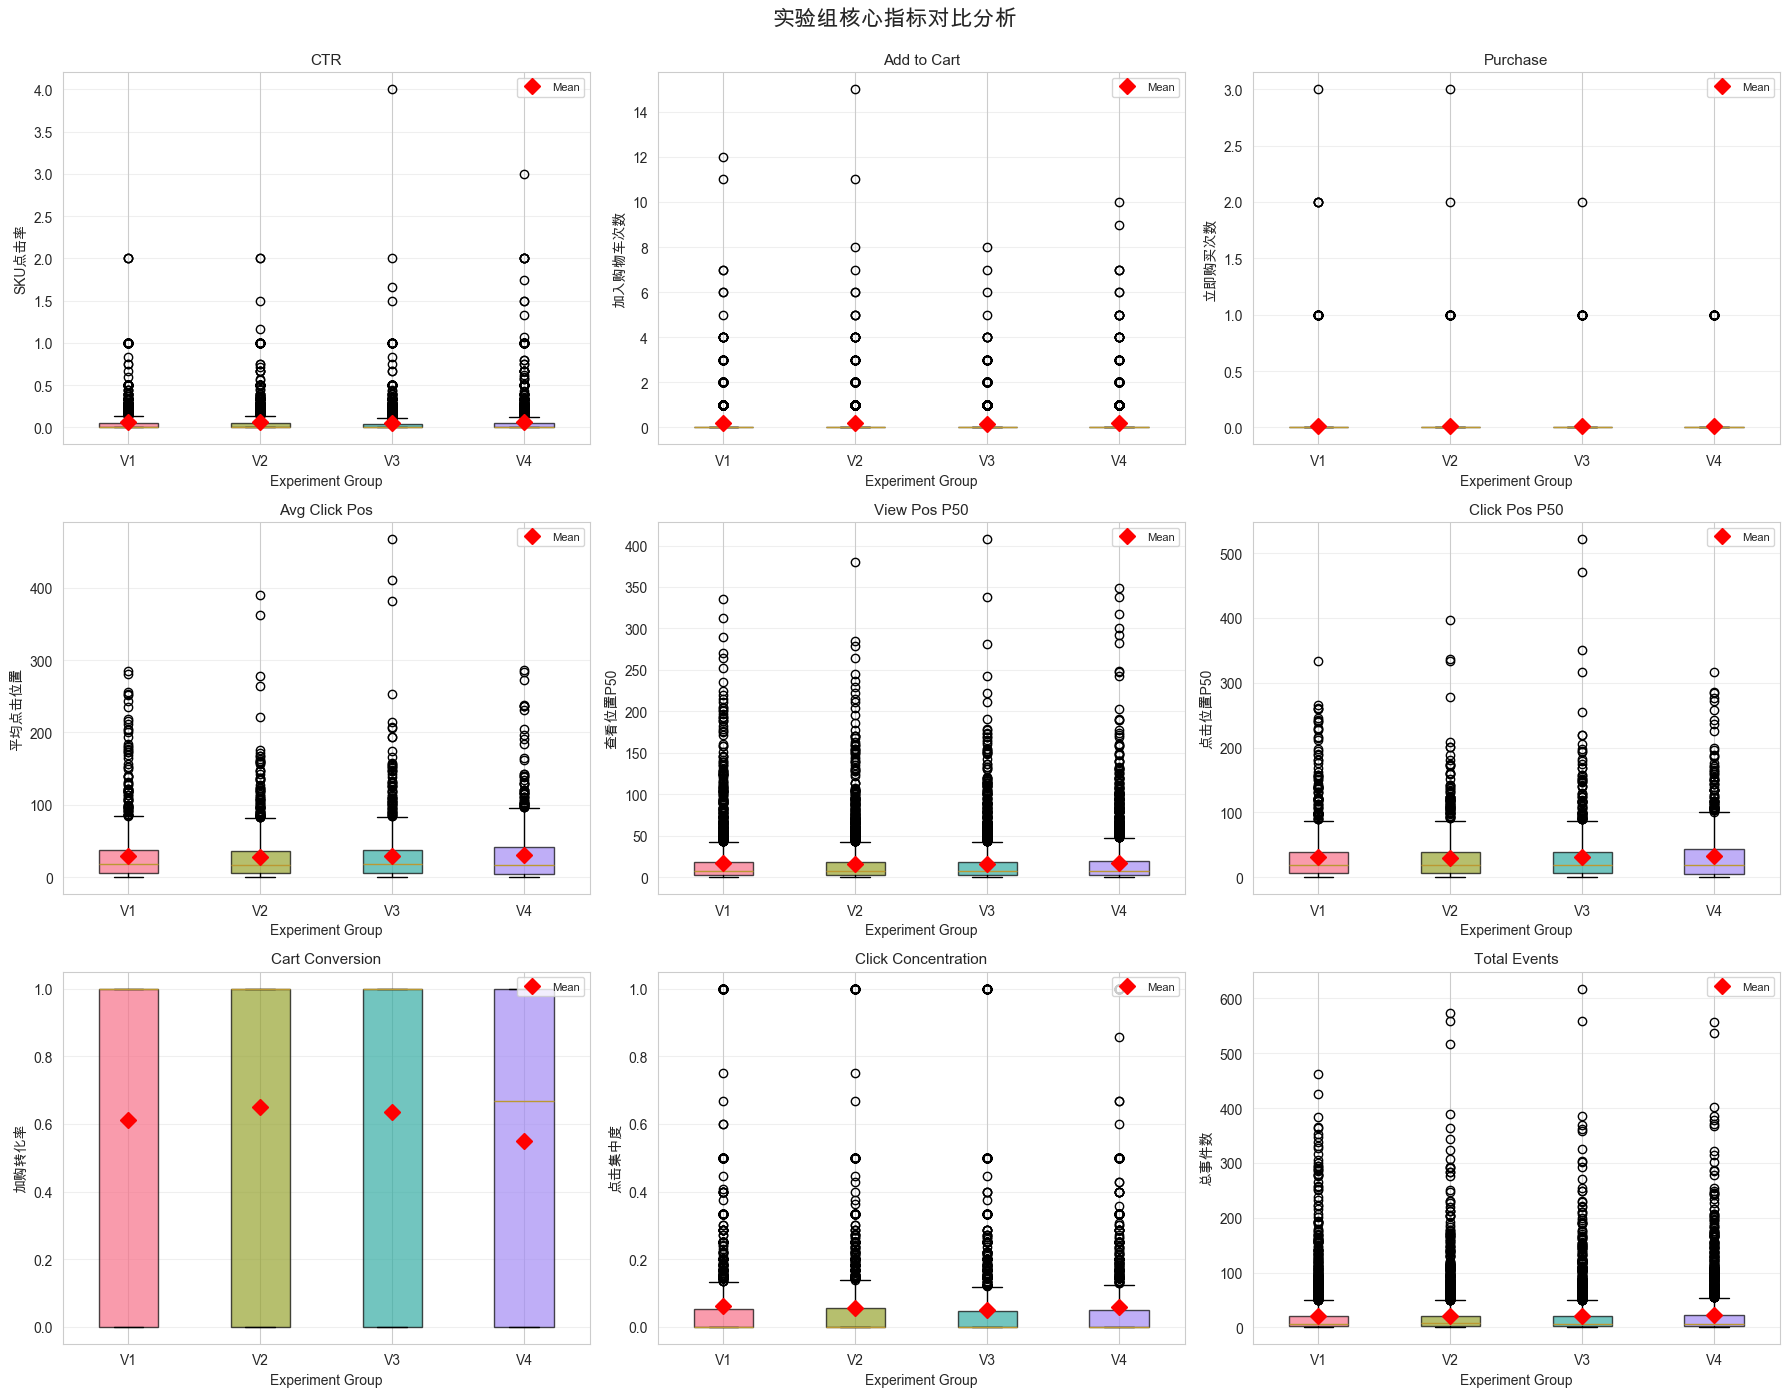

✓ 可视化完成!

五、实验总结报告

【关键指标排名】

SKU点击率:
  🥇 1. V4: 0.0665
  🥈 2. V1: 0.0656
  🥉 3. V2: 0.0595
     4. V3: 0.0540

加入购物车次数:
  🥇 1. V2: 0.1966
  🥈 2. V1: 0.1921
  🥉 3. V4: 0.1795
     4. V3: 0.1660

加购转化率:
  🥇 1. V2: 0.6489
  🥈 2. V3: 0.6347
  🥉 3. V1: 0.6115
     4. V4: 0.5485


【统计显著性汇总】
共有 3/6 个指标存在显著差异 (p<0.05)

显著差异指标:
  ✓ SKU点击率: p=0.022013
  ✓ 加购转化率: p=0.002477
  ✓ 点击集中度: p=0.014966


【实验结论与建议】
  1. ✓ 数据已清理无效值(inf/NaN)，确保分析可靠性
  2. ✓ 关注p<0.05的显著性差异
  3. ✓ 结合效应量评估实际业务价值
  4. ✓ 注意样本量差异对结果的影响

✓ 分析完成!


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
if platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS', 'STHeiti']
elif platform.system() == 'Windows':
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
else:
    plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'DejaVu Sans']

plt.rcParams['axes.unicode_minus'] = False

print(f"✓ 字体已配置: {plt.rcParams['font.sans-serif'][0]}")


class ExperimentAnalyzer:
    """实验组对比分析器（优化版 - 处理inf和NaN）"""
    
    def __init__(self, df, group_col='variant_list'):
        """
        初始化分析器
        """
        self.df = df.copy()
        self.group_col = group_col
        
        print("="*70)
        print("数据清理与预处理")
        print("="*70)
        
        # 1. 清理分组列
        print(f"\n原始数据总样本量: {len(self.df)}")
        print(f"分组列缺失值数量: {self.df[group_col].isna().sum()}")
        
        self.df = self.df[self.df[group_col].notna()].copy()
        self.df[group_col] = self.df[group_col].astype(str)
        
        # 2. 数据类型转换
        numeric_cols = [
            'SKU曝光次数', '被查看SKU数', '被点击SKU数', 'SKU点击次数', 
            'SKU点击率', '前4位SKU点击次数', '前4位SKU点击占比',
            '唤起加购弹窗点击次数', '加入购物车次数', '立即购买次数',
            '平均点击位置', '最大点击位置', '点击位置P50', '点击位置P75', 
            '点击位置P95', '查看位置P50', '查看位置P75', '查看位置P95', '总事件数'
        ]
        
        for col in numeric_cols:
            if col in self.df.columns:
                self.df[col] = pd.to_numeric(self.df[col], errors='coerce')
        
        # 3. 清理无效数据（inf和NaN）
        print("\n清理无效数据...")
        before_clean = len(self.df)
        
        # 替换 inf 为 NaN
        self.df = self.df.replace([np.inf, -np.inf], np.nan)
        
        # 统计每列的无效值
        print("\n各列无效值统计:")
        for col in numeric_cols:
            if col in self.df.columns:
                invalid_count = self.df[col].isna().sum()
                if invalid_count > 0:
                    print(f"  {col}: {invalid_count} ({invalid_count/len(self.df)*100:.1f}%)")
        
        # 4. 计算衍生指标（增加异常值处理）
        self._calculate_derived_metrics()
        
        # 5. 获取实验组信息
        self.groups = sorted(self.df[group_col].unique())
        
        print(f"\n清理后样本量: {len(self.df)}")
        print(f"\n实验组: {self.groups}")
        print(f"\n各组样本量分布:")
        group_counts = self.df[group_col].value_counts().sort_index()
        for group, count in group_counts.items():
            print(f"  {group}: {count} ({count/len(self.df)*100:.1f}%)")
        print()
    
    def _calculate_derived_metrics(self):
        """计算衍生指标（增强异常值处理）"""
        
        # 加购转化率
        self.df['加购转化率'] = np.where(
            (self.df['唤起加购弹窗点击次数'] > 0) & 
            (self.df['唤起加购弹窗点击次数'].notna()),
            self.df['加入购物车次数'] / self.df['唤起加购弹窗点击次数'],
            np.nan  # 分母为0时设为NaN而不是0
        )
        
        # 购买转化率
        self.df['购买转化率'] = np.where(
            (self.df['唤起加购弹窗点击次数'] > 0) & 
            (self.df['唤起加购弹窗点击次数'].notna()),
            self.df['立即购买次数'] / self.df['唤起加购弹窗点击次数'],
            np.nan
        )
        
        # 点击集中度
        self.df['点击集中度'] = np.where(
            (self.df['被查看SKU数'] > 0) & 
            (self.df['被查看SKU数'].notna()),
            self.df['被点击SKU数'] / self.df['被查看SKU数'],
            np.nan
        )
        
        # 浏览深度
        self.df['浏览深度'] = np.where(
            (self.df['SKU曝光次数'] > 0) & 
            (self.df['SKU曝光次数'].notna()),
            self.df['被查看SKU数'] / self.df['SKU曝光次数'],
            np.nan
        )
        
        # 清理衍生指标中的异常值（>1的比率设为NaN）
        for col in ['加购转化率', '购买转化率', '点击集中度', '浏览深度']:
            self.df.loc[self.df[col] > 1, col] = np.nan
            self.df.loc[self.df[col] < 0, col] = np.nan
    
    def descriptive_stats(self):
        """描述性统计分析"""
        print("=" * 80)
        print("一、描述性统计分析")
        print("=" * 80)
        
        metrics = [
            'SKU点击率', '被点击SKU数', '加入购物车次数', '立即购买次数',
            '平均点击位置', '点击位置P50', '查看位置P50',
            '加购转化率', '点击集中度', '浏览深度', '总事件数'
        ]
        
        stats_list = []
        for metric in metrics:
            if metric not in self.df.columns:
                continue
            
            # 过滤有效数据
            valid_data = self.df[self.df[metric].notna()]
            
            if len(valid_data) == 0:
                print(f"\n⚠ 指标 {metric} 无有效数据，跳过")
                continue
            
            group_stats = valid_data.groupby(self.group_col)[metric].agg([
                ('样本量', 'count'),
                ('均值', 'mean'),
                ('中位数', 'median'),
                ('标准差', 'std'),
                ('最小值', 'min'),
                ('最大值', 'max'),
                ('标准误', lambda x: x.sem() if len(x) > 1 else np.nan),
                ('95%CI下限', lambda x: x.mean() - 1.96 * x.sem() if len(x) > 1 else np.nan),
                ('95%CI上限', lambda x: x.mean() + 1.96 * x.sem() if len(x) > 1 else np.nan)
            ]).round(4)
            
            print(f"\n{'='*70}")
            print(f"指标: {metric}")
            print(f"{'='*70}")
            print(group_stats)
            
            group_stats['指标'] = metric
            stats_list.append(group_stats.reset_index())
        
        self.descriptive_results = pd.concat(stats_list, ignore_index=True) if stats_list else pd.DataFrame()
        return self.descriptive_results
    
    def hypothesis_testing(self):
        """假设检验分析"""
        print("\n" + "=" * 80)
        print("二、假设检验分析")
        print("=" * 80)
        
        metrics = [
            'SKU点击率', '加入购物车次数', '立即购买次数',
            '平均点击位置', '加购转化率', '点击集中度'
        ]
        
        test_results = []
        
        for metric in metrics:
            if metric not in self.df.columns:
                continue
            
            print(f"\n{'='*70}")
            print(f"指标: {metric}")
            print(f"{'='*70}")
            
            # 准备数据 - 只使用有效数据
            group_data = []
            valid_groups = []
            
            for g in self.groups:
                data = self.df[self.df[self.group_col] == g][metric].dropna().values
                if len(data) >= 3:  # 至少需要3个样本
                    group_data.append(data)
                    valid_groups.append(g)
                else:
                    print(f"  ⚠ {g} 组有效样本不足 (n={len(data)})，跳过")
            
            if len(group_data) < 2:
                print(f"  ⚠ 有效组少于2个，无法进行检验")
                continue
            
            print(f"\n  参与检验的组: {valid_groups}")
            print(f"  各组样本量: {[len(d) for d in group_data]}")
            
            # 1. ANOVA检验
            try:
                f_stat, p_value = stats.f_oneway(*group_data)
                print(f"\n1. ANOVA检验")
                print(f"   F统计量: {f_stat:.4f}")
                print(f"   P值: {p_value:.6f}")
                
                if p_value < 0.001:
                    sig_label = "*** (极显著)"
                elif p_value < 0.01:
                    sig_label = "** (非常显著)"
                elif p_value < 0.05:
                    sig_label = "* (显著)"
                else:
                    sig_label = "ns (不显著)"
                
                print(f"   结论: {sig_label}")
                
                test_results.append({
                    '指标': metric,
                    '检验方法': 'ANOVA',
                    'F统计量': f_stat,
                    'P值': p_value,
                    '显著性': p_value < 0.05
                })
            except Exception as e:
                print(f"   ANOVA检验失败: {e}")
            
            # 2. 两两比较
            if len(group_data) >= 2:
                print(f"\n2. 两两比较 (t检验 + Bonferroni校正)")
                
                n_comparisons = len(valid_groups) * (len(valid_groups) - 1) // 2
                alpha_corrected = 0.05 / n_comparisons
                
                for i in range(len(valid_groups)):
                    for j in range(i+1, len(valid_groups)):
                        try:
                            t_stat, p_val = stats.ttest_ind(group_data[i], group_data[j])
                            mean_diff = np.mean(group_data[j]) - np.mean(group_data[i])
                            
                            if p_val < alpha_corrected:
                                sig = '***'
                            elif p_val < 0.01:
                                sig = '**'
                            elif p_val < 0.05:
                                sig = '*'
                            else:
                                sig = 'ns'
                            
                            print(f"   {valid_groups[i]} vs {valid_groups[j]}: "
                                  f"均值差={mean_diff:+.4f}, p={p_val:.6f} {sig}")
                        except Exception as e:
                            print(f"   {valid_groups[i]} vs {valid_groups[j]}: 检验失败")
        
        self.test_results = pd.DataFrame(test_results) if test_results else pd.DataFrame()
        return self.test_results
    
    def effect_size_analysis(self):
        """效应量分析"""
        print("\n" + "=" * 80)
        print("三、效应量分析 (Cohen's d)")
        print("=" * 80)
        
        metrics = ['SKU点击率', '加入购物车次数', '加购转化率', '点击集中度']
        baseline = self.groups[0]
        
        def cohens_d(x1, x2):
            n1, n2 = len(x1), len(x2)
            if n1 <= 1 or n2 <= 1:
                return np.nan
            var1, var2 = np.var(x1, ddof=1), np.var(x2, ddof=1)
            pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
            if pooled_std == 0:
                return np.nan
            return (np.mean(x2) - np.mean(x1)) / pooled_std
        
        effect_sizes = []
        
        for metric in metrics:
            if metric not in self.df.columns:
                continue
            
            print(f"\n{'='*70}")
            print(f"指标: {metric}")
            print(f"对照组: {baseline}")
            print(f"{'='*70}")
            
            baseline_data = self.df[self.df[self.group_col] == baseline][metric].dropna().values
            
            if len(baseline_data) < 2:
                print(f"  ⚠ 对照组样本不足，跳过")
                continue
            
            for group in self.groups:
                if group == baseline:
                    continue
                
                group_data = self.df[self.df[self.group_col] == group][metric].dropna().values
                
                if len(group_data) < 2:
                    print(f"  ⚠ {group} 组样本不足，跳过")
                    continue
                
                d = cohens_d(baseline_data, group_data)
                
                if np.isnan(d):
                    interpretation = "无法计算"
                elif abs(d) < 0.2:
                    interpretation = "极小"
                elif abs(d) < 0.5:
                    interpretation = "小"
                elif abs(d) < 0.8:
                    interpretation = "中等"
                else:
                    interpretation = "大"
                
                baseline_mean = np.mean(baseline_data)
                group_mean = np.mean(group_data)
                pct_change = ((group_mean - baseline_mean) / baseline_mean * 100) if baseline_mean != 0 else np.nan
                
                print(f"  {baseline} vs {group}:")
                print(f"    Cohen's d = {d:.4f} ({interpretation})")
                print(f"    {baseline}均值 = {baseline_mean:.4f}")
                print(f"    {group}均值 = {group_mean:.4f}")
                if not np.isnan(pct_change):
                    print(f"    变化率 = {pct_change:+.2f}%")
                
                effect_sizes.append({
                    '指标': metric,
                    '对比': f"{baseline} vs {group}",
                    "Cohen's d": d,
                    '效应量大小': interpretation,
                    '对照组均值': baseline_mean,
                    '实验组均值': group_mean,
                    '变化率%': pct_change
                })
        
        self.effect_sizes = pd.DataFrame(effect_sizes) if effect_sizes else pd.DataFrame()
        return self.effect_sizes

    def hypothesis_testing_with_baseline(self, baseline_group='V2'):
        """假设检验分析 - 明确对照组"""
        print("\n" + "=" * 80)
        print("二、假设检验分析（以对照组为基准）")
        print("=" * 80)
        print(f"\n对照组: {baseline_group}")
        print(f"实验组: {[g for g in self.groups if g != baseline_group]}\n")
        
        metrics = [
            'SKU点击率', '加入购物车次数', '立即购买次数',
            '平均点击位置', '加购转化率', '点击集中度'
        ]
        
        test_results = []
        
        for metric in metrics:
            if metric not in self.df.columns:
                continue
            
            print(f"\n{'='*70}")
            print(f"指标: {metric}")
            print(f"{'='*70}")
            
            # 准备数据
            group_data = []
            valid_groups = []
            
            for g in self.groups:
                data = self.df[self.df[self.group_col] == g][metric].dropna().values
                if len(data) >= 3:
                    group_data.append(data)
                    valid_groups.append(g)
                else:
                    print(f"  ⚠ {g} 组有效样本不足 (n={len(data)})，跳过")
            
            if len(group_data) < 2:
                print(f"  ⚠ 有效组少于2个，无法进行检验")
                continue
            
            # 检查对照组是否在有效组中
            if baseline_group not in valid_groups:
                print(f"  ⚠ 对照组 {baseline_group} 样本不足，改用 {valid_groups[0]} 作为对照组")
                baseline_group = valid_groups[0]
            
            baseline_idx = valid_groups.index(baseline_group)
            baseline_data = group_data[baseline_idx]
            
            print(f"\n各组样本量: {dict(zip(valid_groups, [len(d) for d in group_data]))}")
            
            # 1. 整体ANOVA检验
            try:
                f_stat, p_value = stats.f_oneway(*group_data)
                print(f"\n1. ANOVA检验 (整体差异)")
                print(f"   F统计量: {f_stat:.4f}")
                print(f"   P值: {p_value:.6f}")
                
                if p_value < 0.001:
                    sig_label = "*** (极显著)"
                elif p_value < 0.01:
                    sig_label = "** (非常显著)"
                elif p_value < 0.05:
                    sig_label = "* (显著)"
                else:
                    sig_label = "ns (不显著)"
                
                print(f"   结论: {sig_label}")
                print(f"   解释: 所有组({', '.join(valid_groups)})之间{'存在' if p_value < 0.05 else '不存在'}显著差异")
                
                test_results.append({
                    '指标': metric,
                    '检验方法': 'ANOVA',
                    '对比': f"整体({len(valid_groups)}组)",
                    'F统计量': f_stat,
                    'P值': p_value,
                    '显著性': p_value < 0.05
                })
            except Exception as e:
                print(f"   ANOVA检验失败: {e}")
            
            # 2. 对照组 vs 每个实验组的单独检验
            print(f"\n2. 对照组对比 ({baseline_group} vs 各实验组)")
            print("   " + "="*60)
            
            for i, group in enumerate(valid_groups):
                if group == baseline_group:
                    continue
                
                try:
                    exp_data = group_data[i]
                    t_stat, p_val = stats.ttest_ind(baseline_data, exp_data)
                    
                    baseline_mean = np.mean(baseline_data)
                    exp_mean = np.mean(exp_data)
                    mean_diff = exp_mean - baseline_mean
                    pct_change = (mean_diff / baseline_mean * 100) if baseline_mean != 0 else np.nan
                    
                    # 计算效应量
                    n1, n2 = len(baseline_data), len(exp_data)
                    var1, var2 = np.var(baseline_data, ddof=1), np.var(exp_data, ddof=1)
                    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
                    cohens_d = mean_diff / pooled_std if pooled_std > 0 else np.nan
                    
                    if p_val < 0.001:
                        sig = '***'
                    elif p_val < 0.01:
                        sig = '**'
                    elif p_val < 0.05:
                        sig = '*'
                    else:
                        sig = 'ns'
                    
                    print(f"\n   {baseline_group} vs {group}:")
                    print(f"   ├─ {baseline_group}均值: {baseline_mean:.4f}")
                    print(f"   ├─ {group}均值: {exp_mean:.4f}")
                    print(f"   ├─ 差异: {mean_diff:+.4f} ({pct_change:+.1f}%)")
                    print(f"   ├─ t统计量: {t_stat:.4f}")
                    print(f"   ├─ P值: {p_val:.6f} {sig}")
                    print(f"   └─ Cohen's d: {cohens_d:.4f}")
                    
                    # 结论
                    if p_val < 0.05:
                        direction = "显著高于" if mean_diff > 0 else "显著低于"
                        print(f"   ✓ 结论: {group} {direction} {baseline_group}")
                    else:
                        print(f"   ✗ 结论: {group} 与 {baseline_group} 无显著差异")
                    
                    test_results.append({
                        '指标': metric,
                        '检验方法': 't-test',
                        '对比': f"{baseline_group} vs {group}",
                        't统计量': t_stat,
                        'P值': p_val,
                        '显著性': p_val < 0.05,
                        '均值差': mean_diff,
                        '变化率%': pct_change,
                        "Cohen's d": cohens_d
                    })
                    
                except Exception as e:
                    print(f"   {baseline_group} vs {group}: 检验失败 ({e})")
            
            # 3. 所有两两对比（可选）
            if len(valid_groups) > 2:
                print(f"\n3. 其他两两对比（非对照组之间）")
                print("   " + "="*60)
                
                for i in range(len(valid_groups)):
                    for j in range(i+1, len(valid_groups)):
                        if valid_groups[i] == baseline_group or valid_groups[j] == baseline_group:
                            continue  # 跳过已经比较过的对照组
                        
                        try:
                            t_stat, p_val = stats.ttest_ind(group_data[i], group_data[j])
                            mean_diff = np.mean(group_data[j]) - np.mean(group_data[i])
                            
                            sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
                            
                            print(f"   {valid_groups[i]} vs {valid_groups[j]}: "
                                f"差异={mean_diff:+.4f}, p={p_val:.6f} {sig}")
                        except:
                            pass
        
        self.test_results = pd.DataFrame(test_results) if test_results else pd.DataFrame()
        return self.test_results


    def generate_summary_report_with_baseline(self, baseline_group='V2'):
        """生成总结报告 - 以对照组为中心"""
        print("\n" + "=" * 80)
        print("五、实验总结报告（以对照组为中心）")
        print("=" * 80)
        print(f"\n对照组: {baseline_group}")
        
        key_metrics = ['SKU点击率', '加入购物车次数', '加购转化率']
        
        # 1. 关键指标对比表
        print("\n【关键指标对比表】")
        print(f"\n{'指标':<20} {'对照组':<15} {'实验组':<10} {'均值':<12} {'变化率':<10} {'显著性':<10}")
        print("-" * 80)
        
        for metric in key_metrics:
            if metric not in self.df.columns:
                continue
            
            baseline_data = self.df[self.df[self.group_col] == baseline_group][metric].dropna()
            baseline_mean = baseline_data.mean() if len(baseline_data) > 0 else np.nan
            
            for group in self.groups:
                if group == baseline_group:
                    continue
                
                group_data = self.df[self.df[self.group_col] == group][metric].dropna()
                group_mean = group_data.mean() if len(group_data) > 0 else np.nan
                
                if not np.isnan(baseline_mean) and not np.isnan(group_mean):
                    pct_change = (group_mean - baseline_mean) / baseline_mean * 100
                    
                    # 检查显著性
                    if len(baseline_data) >= 3 and len(group_data) >= 3:
                        _, p_val = stats.ttest_ind(baseline_data, group_data)
                        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
                    else:
                        sig = 'N/A'
                    
                    print(f"{metric:<20} {baseline_mean:>8.4f}      {group:<10} {group_mean:>8.4f}   {pct_change:>+6.1f}%    {sig:<10}")
        
        # 2. 显著性汇总
        if hasattr(self, 'test_results') and len(self.test_results) > 0:
            print("\n\n【显著性检验汇总】")
            
            # 筛选对照组相关的检验
            baseline_tests = self.test_results[
                self.test_results['对比'].str.contains(baseline_group, na=False) & 
                (self.test_results['检验方法'] == 't-test')
            ]
            
            if len(baseline_tests) > 0:
                sig_tests = baseline_tests[baseline_tests['显著性'] == True]
                print(f"\n与对照组 {baseline_group} 相比:")
                print(f"  - 共测试 {len(baseline_tests)} 个对比")
                print(f"  - 显著差异: {len(sig_tests)} 个")
                print(f"  - 无显著差异: {len(baseline_tests) - len(sig_tests)} 个")
                
                if len(sig_tests) > 0:
                    print(f"\n  显著优于对照组的:")
                    for _, row in sig_tests[sig_tests['变化率%'] > 0].iterrows():
                        print(f"    ✓ {row['对比']}: {row['指标']} 提升 {row['变化率%']:.1f}% (p={row['P值']:.4f})")
                    
                    print(f"\n  显著低于对照组的:")
                    for _, row in sig_tests[sig_tests['变化率%'] < 0].iterrows():
                        print(f"    ✗ {row['对比']}: {row['指标']} 下降 {abs(row['变化率%']):.1f}% (p={row['P值']:.4f})")
        
        # 3. 推荐
        print("\n\n【实验结论与推荐】")
        print(f"  基于与对照组 {baseline_group} 的对比:")
        print("  1. ✓ 关注显著性(p<0.05)和效应量(|d|>0.5)的综合判断")
        print("  2. ✓ 优先选择在核心指标上有显著提升的版本")
        print("  3. ✓ 警惕样本量不足导致的假阳性结果")
        print("  4. ✓ 建议进行更长周期的验证实验")
    
    def visualize_comparison(self, save_path=None):
        """可视化对比"""
        print("\n" + "=" * 80)
        print("四、可视化对比分析")
        print("=" * 80)
        
        # 核心指标箱线图
        fig, axes = plt.subplots(3, 3, figsize=(18, 14))
        fig.suptitle('实验组核心指标对比分析', fontsize=16, y=0.995)
        
        metrics_to_plot = [
            ('SKU点击率', 'CTR'),
            ('加入购物车次数', 'Add to Cart'),
            ('立即购买次数', 'Purchase'),
            ('平均点击位置', 'Avg Click Pos'),
            ('查看位置P50', 'View Pos P50'),
            ('点击位置P50', 'Click Pos P50'),
            ('加购转化率', 'Cart Conversion'),
            ('点击集中度', 'Click Concentration'),
            ('总事件数', 'Total Events')
        ]
        
        for idx, (metric, label) in enumerate(metrics_to_plot):
            if metric not in self.df.columns:
                continue
            
            ax = axes[idx // 3, idx % 3]
            
            # 准备数据 - 过滤NaN和异常值
            data_to_plot = []
            labels = []
            for g in self.groups:
                data = self.df[self.df[self.group_col] == g][metric].dropna().values
                if len(data) > 0:
                    data_to_plot.append(data)
                    labels.append(g)
            
            if len(data_to_plot) == 0:
                ax.text(0.5, 0.5, f'{label}\n无有效数据', 
                       ha='center', va='center', fontsize=12)
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1)
                continue
            
            # 绘制箱线图
            bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
            
            colors = sns.color_palette("husl", len(labels))
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            
            # 添加均值点
            means = [np.mean(d) for d in data_to_plot]
            ax.plot(range(1, len(means)+1), means, 'D', color='red', 
                   markersize=8, label='Mean', zorder=3)
            
            ax.set_title(label, fontsize=11, fontweight='bold')
            ax.set_xlabel('Experiment Group')
            ax.set_ylabel(metric)
            ax.grid(axis='y', alpha=0.3)
            ax.legend(loc='upper right', fontsize=8)
        
        plt.tight_layout()
        if save_path:
            plt.savefig(f"{save_path}_boxplots.png", dpi=300, bbox_inches='tight')
        plt.show()
        
        print("✓ 可视化完成!")
    
    def generate_summary_report(self):
        """生成总结报告"""
        print("\n" + "=" * 80)
        print("五、实验总结报告")
        print("=" * 80)
        
        key_metrics = ['SKU点击率', '加入购物车次数', '加购转化率']
        
        print("\n【关键指标排名】")
        for metric in key_metrics:
            if metric not in self.df.columns:
                continue
            
            # 只统计有效数据
            valid_data = self.df[self.df[metric].notna()]
            if len(valid_data) == 0:
                continue
            
            ranking = valid_data.groupby(self.group_col)[metric].mean().sort_values(ascending=False)
            print(f"\n{metric}:")
            for rank, (group, value) in enumerate(ranking.items(), 1):
                emoji = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else "  "
                print(f"  {emoji} {rank}. {group}: {value:.4f}")
        
        if hasattr(self, 'test_results') and len(self.test_results) > 0:
            print("\n\n【统计显著性汇总】")
            sig_results = self.test_results[self.test_results['显著性'] == True]
            print(f"共有 {len(sig_results)}/{len(self.test_results)} 个指标存在显著差异 (p<0.05)")
            
            if len(sig_results) > 0:
                print("\n显著差异指标:")
                for _, row in sig_results.iterrows():
                    print(f"  ✓ {row['指标']}: p={row['P值']:.6f}")
        
        print("\n\n【实验结论与建议】")
        print("  1. ✓ 数据已清理无效值(inf/NaN)，确保分析可靠性")
        print("  2. ✓ 关注p<0.05的显著性差异")
        print("  3. ✓ 结合效应量评估实际业务价值")
        print("  4. ✓ 注意样本量差异对结果的影响")
    
    def run_full_analysis(self, save_path=None):
        """运行完整分析"""
        print("\n" + "="*80)
        print(" " * 20 + "实验组对比完整分析报告")
        print("="*80 + "\n")
        
        self.descriptive_stats()
        self.hypothesis_testing()
        self.effect_size_analysis()
        self.visualize_comparison(save_path)
        self.generate_summary_report()
        
        print("\n" + "="*80)
        print("✓ 分析完成!")
        print("="*80)


# 使用示例
# 创建分析器
analyzer = ExperimentAnalyzer(user_click_with_variant_statistics_df, group_col='variant_list')

# 运行分析（明确指定V1为对照组）
analyzer.descriptive_stats()
analyzer.hypothesis_testing_with_baseline(baseline_group='V2')  # 指定V2为对照组
analyzer.effect_size_analysis()
analyzer.visualize_comparison(save_path='experiment_analysis')
analyzer.generate_summary_report_with_baseline(baseline_group='V2')  # 以V2为中心的报告

In [ ]:
first_view_sql=f"""
select variant_list,uid,count(*) as sku_viewed_cnt
from all_sku_view_data_df
where cast(idx as bigint)<=5
group by variant_list,uid
order by sku_viewed_cnt desc
"""

first_view_sql_df = pandasql.sqldf(first_view_sql)
first_view_sql_df



In [ ]:
first_view_click_sql=f"""
select uid,count(*) as sku_clicked_cnt,min(idx),max(idx),avg(idx)
from all_user_sku_click_df
where idx is not null and idx != 'null' and cast(idx as bigint)<=5
group by uid
order by sku_clicked_cnt desc
"""

first_view_click_sql_df = pandasql.sqldf(first_view_click_sql)
first_view_click_sql_df



In [ ]:
first_view_merged_df=first_view_sql_df.merge(first_view_click_sql_df, on=["uid"], how="left")
first_view_merged_df.head(5)

grouped_first_view_df=first_view_merged_df.groupby("variant_list").agg({"sku_viewed_cnt": "sum", "sku_clicked_cnt": "sum"}).reset_index()
grouped_first_view_df.columns=["variant_list","总浏览量","总点击量"]
grouped_first_view_df.head(5)

first_view_merged_df=first_view_merged_df.merge(grouped_first_view_df, on="variant_list", how="left")
first_view_merged_df=first_view_merged_df.sort_values("总点击量", ascending=False)
first_view_merged_df["是否实验组"]=first_view_merged_df.apply(lambda x: "实验组" if x["variant_list"] in ["V3","V4"] else "对照组" if x["variant_list"] in ["V1","V2"] else "未进实验", axis=1)
first_view_merged_df.head(5)

first_view_merged_stats=pandasql.sqldf("""
select variant_list,是否实验组, sum(sku_viewed_cnt) as 浏览量, sum(sku_clicked_cnt) as 点击量
    ,sum(sku_clicked_cnt)*1.00/sum(sku_viewed_cnt) as 点击率
    ,min(总浏览量) as 总浏览量
from first_view_merged_df 
group by 是否实验组,variant_list
order by min(总浏览量) desc
""")

first_view_merged_stats.to_csv(f"./data/推荐AB-首屏点击分析-{START_DATE}.csv", index=False)
first_view_merged_stats.head(40)

In [ ]:
# controled_group_df=first_view_merged_stats[first_view_merged_stats["是否实验组"]=="对照组"]
# controled_group_dict={}
# for row_index, row in controled_group_df.iterrows():
#     controled_group_dict[row["search_query"]]=row["点击率"]

# first_view_merged_stats["点击率提升"]=first_view_merged_stats.apply(lambda row: 100.00*(row["点击率"]/controled_group_dict.get(row["search_query"],0.01) - 1), axis=1)
# first_view_merged_stats["点击率提升"]=first_view_merged_stats["点击率提升"].round(2)
# first_view_merged_stats.to_csv(f"./data/推荐AB-首屏点击分析-点击率提升-{START_DATE}.csv",index=False)
# first_view_merged_stats.head(50)

In [ ]:
first_view_merged_total_stats=pandasql.sqldf("""
select 是否实验组, sum(sku_viewed_cnt) as 浏览量, sum(sku_clicked_cnt) as 点击量
    ,sum(sku_clicked_cnt)*1.00/sum(sku_viewed_cnt) as 点击率
from first_view_merged_df 
group by 是否实验组
""")
first_view_merged_total_stats

In [ ]:
user_view_with_variant_statistics_df=pandasql.sqldf("""
select a.uid,a.ds,b.variant_list,count(a.sku) as 商品查看cnt
from all_user_sku_view_df a
left join all_user_variant_df b on a.uid = b.uid and a.ds = b.ds
group by a.uid,a.ds,b.variant_list
""")

all_data_df = user_view_with_variant_statistics_df.merge(
    user_click_with_variant_statistics_df, on=["uid", "ds", "variant_list"], how="left"
)
# 定义计数列名列表
count_columns = ["商品详情cnt", "加入购物车cnt", "唤起购买cnt", "首屏总点击cnt", "总点击cnt"]
# 遍历计数列
for col in count_columns:
    # 将空值填充为0并转换为整数类型
    all_data_df[col] = all_data_df[col].fillna(0).astype(int)

# 创建 "用户是否点击" 列
all_data_df["用户是否点击"] = (all_data_df["总点击cnt"] > 0).astype(int)

# 定义费率计算相关列名列表
rate_columns = [
    ("sku_click_rate", "商品详情cnt", "商品查看cnt"), # 商品详情点击率
    ("add_cart_rate", "加入购物车cnt", "商品查看cnt"), # 加入购物车率
    ("popup_click_rate", "唤起购买cnt", "商品查看cnt"), # 唤起购买率
]

# 遍历费率列
for rate_col, num_col, den_col in rate_columns:
    # 计算费率，空值填充0，保留5位小数，转换为浮点数
    all_data_df[rate_col] = (all_data_df[num_col] / all_data_df[den_col]).fillna(0).round(5).astype(float)

all_data_df.head(5)

In [ ]:
from IPython.core.display import HTML
import pandas as pd

css = """
<link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/bootstrap@4.0.0/dist/css/bootstrap.min.css" integrity="sha384-Gn5384xqQ1aoWXA+058RXPxPg6fy4IWvTNh0E263XmFcJlSAwiGgFAW/dAiS6JXm" crossorigin="anonymous">
<style type=\"text/css\">
#abTesting table,#abTesting .table {
    color: #333;
    font-family: unset;
    font-size: 12px;
    line-height: 1.5;
    width: 95vw;
    border-collapse:
    collapse; 
    border-spacing: 0;
    font-family: "SF Pro SC", "SF Pro Text", "SF Pro Icons", "PingFang SC", "Helvetica Neue", "Helvetica", "Arial", sans-serif;
}

body{
    padding-left: 1rem;
    padding-top: 1vh;
}

tr{
    border-bottom: 1px solid #C1C3D1;
}

tr:nth-child(even) {
    background-color: #F8F8F8;
}

#abTesting td, #abTesting th {
    /* border: 1px solid transparent; No more visible border */
    height: 30px;
    padding: 0.2rem;
}

#abTesting table tbody td,#abTesting .table tbody td{
    padding: 0.1rem .75rem;
    vertical-align: middle;
}

th {
    background-color: #DFDFDF; /* Darken header a bit */
    font-weight: bolder;
    font-size: larger;
    color: #000;
    text-align: center;
}
</style>
"""


def display_p_value_below_005(row: pd.Series, p_value_col_name: str = "p_value"):
    p_value = row[p_value_col_name]
    color = "black"
    if p_value is not None and p_value <= 0.05:
        color = "red"
    return f"""<span style='font-weight:bolder;color:{color};'>{p_value}</span>"""


def display_diff_to_v2(row: pd.Series, metric: str = "diff_to_v2%"):
    diff = row[metric]
    color = "green"
    if diff is not None and float(diff) > 0.0:
        color = "red"
    return f"""<span style='font-weight:bolder;color:{color};'>{diff:.4f} %</span>"""


def dataframe_to_html(df: pd.DataFrame, title: str):
    df_to_display = df.copy()

    df_to_display["p_value"] = df_to_display.apply(display_p_value_below_005, axis=1)
    df_to_display["diff_to_v2%"] = df_to_display.apply(display_diff_to_v2, axis=1)

    html_df = df_to_display.to_html(
        escape=False, index=False, classes="table dataframe"
    )
    html_content = f"""<html><head><meta charset="UTF-8">
    <meta name="title" content="{title}">
    {css}
    </head><body>
    <h2>{title}</h2>
    <h4>当P-value <= 0.05时表示实验结果统计学显著</h4>
    <span>统计学显著时，既可能表示该试验组是好于对照组，也可能是坏于对照组</span>
    <div id="abTesting">{html_df}</div></body></html>"""

    return html_content

In [ ]:
import pandas as pd
from scipy.stats import ttest_ind


def calculate_p_values(
    df: pd.DataFrame,
    metric: str = "商品详情cnt",
    control_variant: str = "V2",
) -> pd.DataFrame:
    """
    Calculate p-values for each combination of category1 and page_name.
    Compares metric between control group (V1) and each of V2, V3, V4.

    Parameters:
    - df (pd.DataFrame): The input DataFrame containing A/B test data.
    - metric (str): The metric column to be analyzed (default is 'added_quantity').

    Returns:
    - pd.DataFrame: A DataFrame with category1, page_name, variant, p-value, and statistics columns.
    """
    p_values = []

    control = df[df["variant_list"] == control_variant][metric]
    control_avg = control.mean()

    for variant in ["V1", "V2", "V3", "V4"]:
        test_group = df[df["variant_list"] == variant]
        test = test_group[metric]

        # print(
        #     f'variant:{variant}, test_group ds length: {len(test_group["ds"].unique())}'
        # )
        if len(test_group["ds"].unique()) <= 0:
            continue

        # Calculate statistics
        stats = {
            "均值": round(test.mean(), 4),
            "std": round(test.std(), 4),
            f"diff_to_{control_variant}%".lower(): round(
                100.00 * (test.mean() - control_avg) / control_avg, 2
            ),
            "q50": test.quantile(0.5),
            "q75": test.quantile(0.75),
            "q90": test.quantile(0.9),
            "q95": test.quantile(0.95),
            "q97": test.quantile(0.97),
            "q99": test.quantile(0.99),
            "q995": test.quantile(0.995),
            "max": test.max(),
            "日均总数": round(test.sum() / len(test_group["ds"].unique())),
            "日均实验UV": round(
                len(test_group[["uid", "ds"]].drop_duplicates())
                / len(test_group["ds"].unique())
            ),
            "日均转化UV": round(
                len(test_group[test_group[metric] > 0][["uid", "ds"]].drop_duplicates())
                / len(test_group["ds"].unique())
            ),
            "日期范围": f"{test_group['ds'].min()}~{test_group['ds'].max()}".replace(
                "2025", ""
            ),
            "metric": metric,
        }

        # Ensure both groups have enough data for a valid t-test
        if len(control) > 1 and len(test) > 1:
            # Perform independent t-test
            stat, p_val = ttest_ind(control, test, equal_var=False, nan_policy="omit")
            p_values.append(
                {
                    "variant_list": variant,
                    "p_value": round(p_val, 4),
                    **stats,
                }
            )
            # print(f"stat:{stat}")
        else:
            # Not enough data for statistical testing
            p_values.append(
                {
                    "variant_list": variant,
                    "p_value": None,
                    **stats,
                }
            )

    return pd.DataFrame(p_values)

In [ ]:
# Define the desired order for sorting
variant_order = ["V1", "V2", "V3", "V4"]


# Create a custom sort key function
def sort_key(variant):
    # Split variant by commas
    parts = variant.split(",")
    # Determine the order based on the first variant in the list
    if parts[0] in variant_order:
        return variant_order.index(parts[0])
    else:
        return len(variant_order)  # Place all other variants after V1, V2, V3, V4


metrics_list = [
    "sku_click_rate",
    "avg点击位置",
    "唤起购买cnt",
    "总点击cnt",
    "商品详情cnt",
    "加入购物车cnt",
    "商品查看cnt",
]
all_p_values_df = pd.DataFrame()
for metric in metrics_list:
    all_p_values_of_same_metric_df = pd.DataFrame()

    p_values_df = calculate_p_values(
        all_data_df,
        metric=metric,
    )

    p_values_df["variant_list"] = p_values_df["variant_list"].apply(
        lambda x: x if x in variant_order else "X_" + x
    )
    p_values_df = p_values_df.sort_values(
        by="variant_list", key=lambda x: x.map(sort_key)
    )
    p_values_df["variant_list"] = p_values_df["variant_list"].str.replace("X_", "")
    all_p_values_of_same_metric_df = pd.concat(
        [all_p_values_of_same_metric_df, p_values_df], ignore_index=True
    )
    all_p_values_df = pd.concat([all_p_values_df, p_values_df], ignore_index=True)

    title = f"推荐AB--{metric}_p-value分布-{p_values_df.iloc[0]['日期范围']}"

    html_content = dataframe_to_html(df=all_p_values_of_same_metric_df, title=title)
    file_path = f"./data/{title}.html"

    # 保存HTML到本地文件：
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(html_content)

    print(f"写入HTML成功！{file_path}")


all_p_values_df = all_p_values_df[['metric', 'variant_list', 'p_value', '均值', 'std', 'diff_to_v2%', 
         'q50', 'q75', 'q90', 'q95', 'q97', 'q99', 'q995', 'max', '日均总数', 
         '日均实验UV', '日均转化UV', '日期范围']]

title_all = f"推荐AB--指标全集_p-value分布-{all_p_values_df.iloc[0]['日期范围']}"
html_content = dataframe_to_html(df=all_p_values_df, title=title_all)
file_path = f"./data/{title_all}.html"

# 保存HTML到本地文件：
with open(file_path, "w", encoding="utf-8") as f:
    f.write(html_content)

print(f"写入HTML成功！{file_path}")
# 根据你的截图，完整的列顺序调整为：
all_p_values_df

In [ ]:
# 导入odps_client库中的两个函数：get_odps_sql_result_as_df 用于执行SQL查询并将结果作为DataFrame返回, write_pandas_df_into_odps 用于将pandas DataFrame写入ODPS表
from odps_client import get_odps_sql_result_as_df, write_pandas_df_into_odps

# 定义分区规范字符串，使用当前日期（年-月-日格式）作为分区值
partition_spec = f"pt={datetime.now().strftime('%Y%m%d')}"

# 将DataFrame写入ODPS表
write_pandas_df_into_odps(
    df=all_user_variant_df,  # 要写入的DataFrame，这里是all_user_variant_df，包含了所有用户的变体信息
    table_name="summerfarm_ds.temp_recommend_ab_all_data_df",  # ODPS表名
    partition_spec=partition_spec,  # 分区规范
    overwrite=True,  # 如果表或分区已存在，是否覆盖
    lifecycle=30,  # 设置表的生命周期为30天
)

# 只分析哪些进入过搜索页面的用户的订单转化结果

# 将开始日期格式化为字符串（年-月-日）
start_date_str = start_date.strftime("%Y-%m-%d")

# 定义SQL查询字符串，用于获取用户订单数据.
# 这段SQL的目的是：从订单表和用户分流表中，根据用户ID和日期进行关联，
# 统计每个用户在不同实验变体下的订单总金额、订单数量和平均订单金额。
order_query = f"""
with user_orders as (
    SELECT  m_id
        ,total_price
        ,order_no
        ,DATE_FORMAT(order_time,'yyyyMMdd') as order_date
    FROM    summerfarm_tech.ods_orders_df
    WHERE   ds = MAX_PT('summerfarm_tech.ods_orders_df')
    AND     status IN (2,3,6)
    AND     order_time >= '{start_date_str} 00:00:00'
    AND     m_size = '单店'
),user_variants as (
    select ds as event_date,uid,variant_list
    from summerfarm_ds.temp_recommend_ab_all_data_df
    where pt=max_pt('summerfarm_ds.temp_recommend_ab_all_data_df')
)
select a.event_date,a.uid,a.variant_list,sum(b.total_price) as order_gmv,
    count(b.order_no) as order_cnt,round(sum(b.total_price)/count(b.order_no),2) as avg_order_gmv
from user_variants a
left join user_orders b on a.uid=b.m_id and a.event_date=b.order_date
group by a.event_date,a.uid,a.variant_list
"""

# 执行SQL查询并将结果作为DataFrame返回
user_orders_df = get_odps_sql_result_as_df(order_query)
# 显示DataFrame的前两行
user_orders_df.head(2)

In [ ]:
user_orders_df["order_gmv"]=user_orders_df["order_gmv"].astype(float)
user_orders_df["avg_order_gmv"]=user_orders_df["avg_order_gmv"].astype(float)
user_orders_df["order_cnt"]=user_orders_df["order_cnt"].astype(int)
user_orders_df[user_orders_df["order_gmv"]>0]["order_gmv"].describe()

In [ ]:
print(
    f"所有订单的分布:\n",
    user_orders_df[user_orders_df["order_gmv"]>0]["order_gmv"].quantile(
        [0.5, 0.75, 0.95, 0.99, 0.995, 0.996, 0.997, 0.999, 1]
    ),
)


# 这里排除哪些高单价的订单，否则对于数据分析来说不好处理。
user_orders_below_6k_df = user_orders_df[user_orders_df["order_gmv"] <= 6000]
print(
    "排除高单价的订单后的分布:\n",
    user_orders_below_6k_df["order_gmv"].quantile(
        [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    ),
)

In [ ]:
user_orders_below_6k_df["order_gmv"].fillna(0, inplace=True)
user_orders_below_6k_df["order_gmv"] = user_orders_below_6k_df["order_gmv"].astype(
    float
)

user_orders_below_6k_df["avg_order_gmv"].fillna(0.0, inplace=True)
user_orders_below_6k_df["avg_order_gmv"] = user_orders_below_6k_df[
    "avg_order_gmv"
].astype(float)

user_orders_below_6k_df["category1"] = "ignore"
user_orders_below_6k_df["page_name"] = "ignore"

user_orders_during_ab_df = user_orders_below_6k_df[
    user_orders_below_6k_df["variant_list"].isin(["V1", "V2", "V3", "V4"])
]
user_orders_during_ab_df.rename(columns={"event_date": "ds"}, inplace=True)

all_order_pvalue_df = pd.DataFrame()
for metric in ["order_gmv", "avg_order_gmv", "order_cnt"]:
    gmv_df = calculate_p_values(df=user_orders_during_ab_df, metric=metric)
    display(gmv_df)
    all_order_pvalue_df = pd.concat([all_order_pvalue_df, gmv_df], ignore_index=True)

title = f"推荐AB--订单转化p-value分布-{all_order_pvalue_df.iloc[0]['日期范围']}"
html_content = dataframe_to_html(df=all_order_pvalue_df, title=title)
file_path = f"./data/{title}.html"

# 保存HTML到本地文件：
with open(file_path, "w", encoding="utf-8") as f:
    f.write(html_content)

print(f"写入HTML成功！{file_path}")
display(all_order_pvalue_df)

In [ ]:
all_p_values_df.to_csv(
    f"./data/推荐AB--所有指标p-value分布-{all_p_values_df.iloc[0]['日期范围']}.csv",
    index=False,
)
all_order_pvalue_df.to_csv(
    f"./data/推荐AB--订单转化p-value分布-{all_p_values_df.iloc[0]['日期范围']}.csv",
    index=False,
)